# Optimale Locaties voor EV-Laadpalen in Amsterdam

Deze notebook doorloopt stap voor stap de ruimtelijke analyse (met
GeoPandas) om de beste locaties voor nieuwe elektrische laadpalen in
Amsterdam te bepalen, op basis van **echte open data**.

**Methode:**
1. Buurtgrenzen, bestaande laadpalen en bevolkingsdichtheid inladen
2. Rondom bestaande laadpalen een dekkingsgebied (buffer) van 250 m maken
3. De gebieden buiten dit dekkingsgebied opsporen
4. Buurten met hoge bevolkingsdichtheid maar lage laadpaaldekking
   identificeren
5. Binnen deze buurten kandidaatpunten genereren, scoren en de beste 10
   selecteren
6. De resultaten tonen op een interactieve Folium-kaart

> **Gebruikte databronnen:**
> - **Buurtgrenzen**: Gemeente Amsterdam, buurtindeling met CBS-buurtcodes (517 buurten)
> - **Bevolking**: CBS, "Kerncijfers wijken en buurten" (tabel 86165NED), aantal inwoners per buurt
> - **Bestaande laadpalen**: Open Charge Map (OCM), 673 laadlocaties in Amsterdam
>
> De ruwe bronbestanden staan in `data/ruw/`; `src/verwerk_echte_data.py`
> zet ze om naar de bruikbare bestanden in `data/echt/` die deze notebook
> gebruikt. Zie de README voor details.

In [1]:
import sys
sys.path.append('../src')

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

from analyse import (
    laad_data, buffer_bestaande_laadpalen, onbedekt_gebied,
    bepaal_prioriteitsbuurten, genereer_kandidaatpunten,
    score_kandidaten, verwijder_te_dichtbij, top_n_locaties
)

DATA_DIR = '../data/echt'
plt.rcParams['figure.figsize'] = (9, 9)

## 1. Data inladen

In [2]:
buurten, laadpalen = laad_data(
    f'{DATA_DIR}/buurten_amsterdam.geojson',
    f'{DATA_DIR}/ev_laadpalen_bestaand.geojson'
)

print(f'{len(buurten)} buurten, {len(laadpalen)} bestaande laadpalen geladen')
buurten.head()

517 buurten, 673 bestaande laadpalen geladen


,buurt_naam,stadsdeel,bevolking,oppervlakte_km2,bev_dichtheid,geometry
0,Planciusbuurt-Noord,Centrum,325,0.0240,13522.5,"POLYGON ((4.88304 52.386, 4.88408 52.38567, 4...."
1,Westelijke eilanden,Centrum,2915,0.2157,13511.6,"POLYGON ((4.88393 52.38551, 4.88465 52.3852, 4..."
2,Westerdokseiland,Centrum,1845,0.3365,5483.2,"POLYGON ((4.89018 52.3824, 4.89064 52.38218, 4..."
3,Planciusbuurt-Zuid,Centrum,160,0.0173,9251.8,"POLYGON ((4.88167 52.38418, 4.88254 52.38392, ..."
4,Haarlemmerbuurt-West,Centrum,2395,0.1169,20491.1,"POLYGON ((4.88261 52.38389, 4.88294 52.3837, 4..."


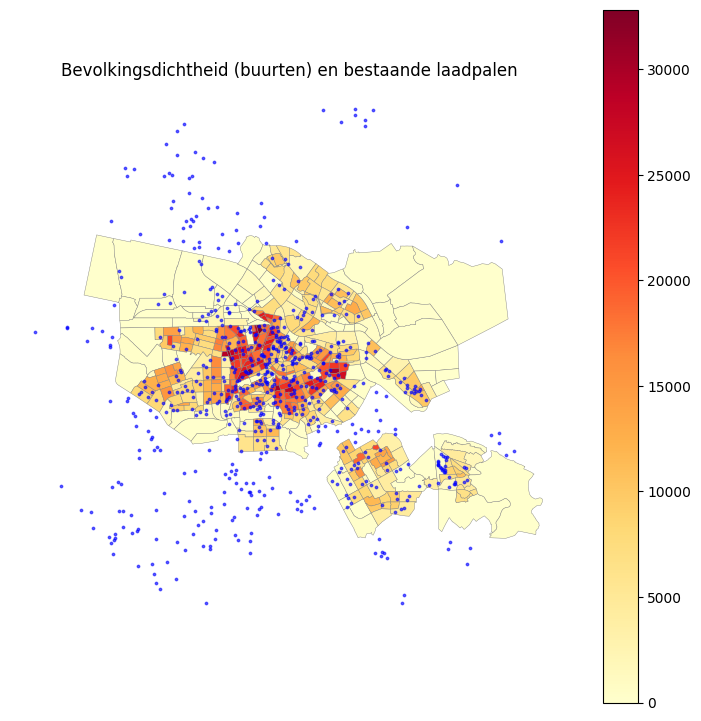

In [3]:
fig, ax = plt.subplots()
buurten.plot(column='bev_dichtheid', cmap='YlOrRd', legend=True, ax=ax,
             edgecolor='grey', linewidth=0.3)
laadpalen.plot(ax=ax, color='blue', markersize=3, alpha=0.6)
ax.set_title('Bevolkingsdichtheid (buurten) en bestaande laadpalen')
ax.set_axis_off()
plt.show()

## 2. Buffer van 250 m en gebieden buiten dekking

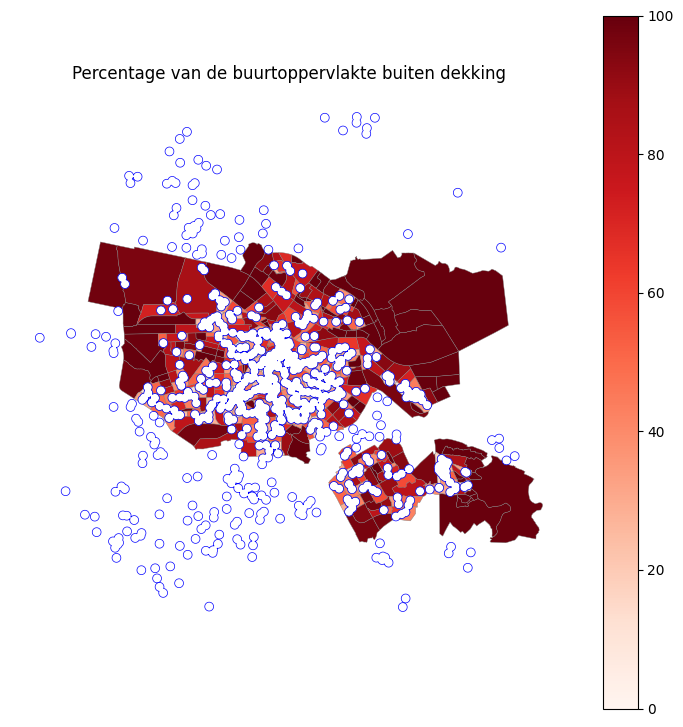

,buurt_naam,stadsdeel,bev_dichtheid,pct_onbedekt
365,Sportpark Middenmeer-Noord,Oost,919.8,100.0
367,Sportpark Voorland,Oost,0.0,100.0
385,Cornelis Douwesterrein-West,Noord,8.5,100.0
91,Spaarndammerbuurt-Zuidwest,West,24236.8,100.0
90,Spaarndammerbuurt-Midden,West,24950.1,100.0
372,Overamstel,Oost,42.1,100.0
76,Vlothaven,Westpoort,0.0,100.0
100,Laan van Spartaan,West,16805.2,100.0
443,Zwarte Gouw,Noord,22.0,100.0
75,Coenhaven,Westpoort,860.8,100.0


In [4]:
dekking = buffer_bestaande_laadpalen(laadpalen, buffer_m=250)
gat = onbedekt_gebied(buurten, dekking)

fig, ax = plt.subplots()
gat.plot(column='pct_onbedekt', cmap='Reds', legend=True, ax=ax,
         edgecolor='grey', linewidth=0.3)
dekking.boundary.plot(ax=ax, color='blue', linewidth=0.5)
ax.set_title('Percentage van de buurtoppervlakte buiten dekking')
ax.set_axis_off()
plt.show()

gat[['buurt_naam','stadsdeel','bev_dichtheid','pct_onbedekt']].sort_values('pct_onbedekt', ascending=False).head(10)

## 3. Prioriteitsbuurten

Buurten met een bevolkingsdichtheid boven de mediaan **en** waarvan
minstens 35% van de oppervlakte buiten het dekkingsgebied van 250 m valt =
prioriteitsgebieden voor nieuwe laadpalen.

In [5]:
prioriteit = bepaal_prioriteitsbuurten(gat, dichtheid_percentiel=0.4, min_pct_onbedekt=35.0)
print(f'{len(prioriteit)} prioriteitsbuurten gevonden')
prioriteit[['buurt_naam','stadsdeel','bev_dichtheid','pct_onbedekt']]

147 prioriteitsbuurten gevonden


,buurt_naam,stadsdeel,bev_dichtheid,pct_onbedekt
124,Orteliusbuurt-Noord,West,30618.5,39.3
326,Timorpleinbuurt-Zuid,Oost,30098.3,36.9
250,Hercules Seghersbuurt,Zuid,30047.5,62.6
123,Mercatorpark,West,29043.3,67.7
330,Sumatraplantsoenbuurt,Oost,26594.6,72.1
...,...,...,...,...
425,Bloemenbuurt-Zuid,Noord,6873.7,35.1
468,Aetsveld-Zuid,Weesp,6844.1,100.0
424,Bloemenbuurt-Noord,Noord,6809.0,53.7
218,Nieuw-Sloten-Noordoost,Nieuw-West,6762.0,42.9


## 4. Kandidaatpunten genereren en scoren

Score = 0,45 × dichtheid + 0,35 × afstand tot dichtstbijzijnde laadpaal + 0,20 × aandeel onbedekt (alles genormaliseerd naar 0-1, op een schaal van 100).

In [6]:
kandidaten = genereer_kandidaatpunten(prioriteit, punten_per_buurt=4)
gescoord = score_kandidaten(kandidaten, laadpalen)
gespreid = verwijder_te_dichtbij(gescoord, min_afstand_m=300)

print(f'{len(kandidaten)} kandidaten gegenereerd -> {len(gespreid)} kandidaten (na filter van 300 m onderlinge afstand)')
gespreid.head(10)[['buurt_naam','stadsdeel','bev_dichtheid','afstand_tot_dichtstbijzijnde_laadpaal_m','score']]

588 kandidaten gegenereerd -> 201 kandidaten (na filter van 300 m onderlinge afstand)


,buurt_naam,stadsdeel,bev_dichtheid,afstand_tot_dichtstbijzijnde_laadpaal_m,score
21,Spaarndammerbuurt-Midden,West,24950.1,571.9,66.3
11,Hercules Seghersbuurt,Zuid,30047.5,340.9,59.8
14,Mercatorpark,West,29043.3,325.0,58.4
494,Banne-Noordoost,Noord,7802.0,1192.1,57.0
205,Reimerswaal,Nieuw-West,13971.7,879.4,57.0
25,Zaagpoortbuurt,Centrum,24729.6,390.0,56.8
19,Sumatraplantsoenbuurt,Oost,26594.6,383.8,56.8
6,Timorpleinbuurt-Zuid,Oost,30098.3,393.6,56.7
38,Spaarndammerbuurt-Zuidwest,West,24236.8,320.0,55.6
58,De Wester Quartier,West,22081.2,450.6,55.0


## 5. Resultaat: top 10 beste nieuwe laadpaallocaties

In [7]:
top10, lagen = top_n_locaties(
    f'{DATA_DIR}/buurten_amsterdam.geojson',
    f'{DATA_DIR}/ev_laadpalen_bestaand.geojson',
    n=10
)
top10[['rangorde','buurt_naam','stadsdeel','bev_dichtheid','afstand_tot_dichtstbijzijnde_laadpaal_m','pct_onbedekt','score']]

,rangorde,buurt_naam,stadsdeel,bev_dichtheid,afstand_tot_dichtstbijzijnde_laadpaal_m,pct_onbedekt,score
0,1,Spaarndammerbuurt-Midden,West,24950.1,571.9,100.0,66.3
1,2,Hercules Seghersbuurt,Zuid,30047.5,340.9,62.6,59.8
2,3,Mercatorpark,West,29043.3,325.0,67.7,58.4
3,4,Banne-Noordoost,Noord,7802.0,1192.1,100.0,57.0
4,5,Reimerswaal,Nieuw-West,13971.7,879.4,100.0,57.0
5,6,Zaagpoortbuurt,Centrum,24729.6,390.0,88.6,56.8
6,7,Sumatraplantsoenbuurt,Oost,26594.6,383.8,72.1,56.8
7,8,Timorpleinbuurt-Zuid,Oost,30098.3,393.6,36.9,56.7
8,9,Spaarndammerbuurt-Zuidwest,West,24236.8,320.0,100.0,55.6
9,10,De Wester Quartier,West,22081.2,450.6,93.3,55.0


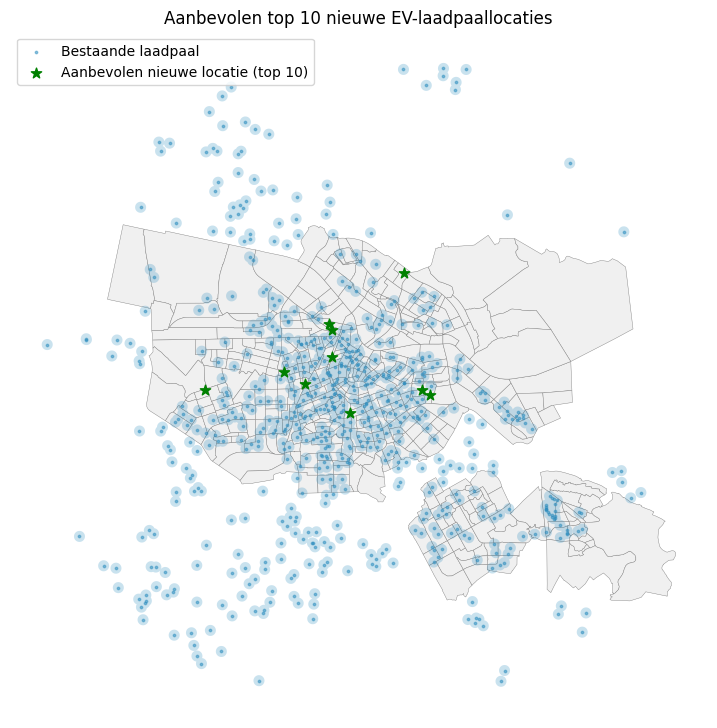

In [8]:
fig, ax = plt.subplots()
buurten.plot(ax=ax, color='#f0f0f0', edgecolor='grey', linewidth=0.3)
dekking.plot(ax=ax, color='#2b8cbe', alpha=0.25)
laadpalen.plot(ax=ax, color='#2b8cbe', markersize=3, alpha=0.5, label='Bestaande laadpaal')
top10.plot(ax=ax, color='green', markersize=60, marker='*', label='Aanbevolen nieuwe locatie (top 10)')
ax.set_title('Aanbevolen top 10 nieuwe EV-laadpaallocaties')
ax.set_axis_off()
plt.legend()
plt.show()

## 6. Interactieve Folium-kaart

Een interactieve kaart met alle lagen (bevolkingsdichtheid, dekkingsgebied, bestaande laadpalen, aanbevolen top 10) wordt opgeslagen als `outputs/interactieve_kaart.html` en hieronder ook direct in de notebook getoond.

In [9]:
import sys
sys.path.append('../src')
from bouw_kaart import bouw_kaart

kaart_pad = bouw_kaart()

from IPython.display import IFrame
IFrame(src='../outputs/interactieve_kaart.html', width='100%', height=600)

Kaart opgeslagen als outputs/interactieve_kaart.html
Top 10 CSV opgeslagen als outputs/top10_kandidaten.csv


## Resultaten exporteren

De top 10 locaties zijn opgeslagen in `outputs/top10_kandidaten.csv`, de
kaart in `outputs/interactieve_kaart.html`. Deze bestanden kunnen ook
rechtstreeks in QGIS worden geladen (CSV -> "Add Delimited Text Layer",
kies de kolommen lat/lon als X/Y).